# Классификация с помощью дерева решений

**Выполнил**: *Никончук В.И. ЕТ-443*

**Постановка задачи**:

1. Разработайте программу, которая выполняет классификацию заданного набора данных с помощью дерева решений. Параметрами программы являются набор данных, критерий выбора атрибута разбиения (Information gain, Gain ratio, Gini index).

2. Проведите эксперименты на наборе Census Income (данные о результатах переписи населения, в т.ч. о годовом доходе -- ниже или выше $50000: скачать обучающую выборку в формате CSV, тестовую выборку в формате CSV, скачать описание). В качестве обучающей выборки для построения дерева используйте 100% исходных данных.

3. Выполните визуализацию построенных деревьев решений.

4. Доработайте программу, добавив в список ее параметров долю, которую занимает обучающая выборка от общего размера набора данных, и обеспечив вычисление и выдачу в качестве результатов следующих показателей качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера.

5. Проведите эксперименты на наборе данных, фиксируя критерий выбора атрибута разбиения и варьируя соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 10%.

6. Выполните визуализацию полученных результатов в виде следующих диаграмм:

 - построенные деревья решений для заданного набора данных;
 - показатели качества классификации в зависимости от соотношения мощностей обучающей и тестовой выборок для заданного набора данных.

7. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  

 - формулировка задания; 
 - гиперссылка на каталог репозитория с исходными текстами, наборами данных и др. сопутствующими материалами; 
 - рисунки с результатами визуализации; 
 - пояснения, раскрывающие смысл полученных результатов.

## **Задания 1-3**

1. Разработайте программу, которая выполняет классификацию заданного набора данных с помощью дерева решений. Параметрами программы являются набор данных, критерий выбора атрибута разбиения (Information gain, Gain ratio, Gini index).

2. Проведите эксперименты на наборе Census Income (данные о результатах переписи населения, в т.ч. о годовом доходе -- ниже или выше $50000: скачать обучающую выборку в формате CSV, тестовую выборку в формате CSV, скачать описание). В качестве обучающей выборки для построения дерева используйте 100% исходных данных.

3. Выполните визуализацию построенных деревьев решений.

## Подключение библиотек

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from typing import Callable, Dict, List
from numpy.typing import ArrayLike



## Чтение данных

Загрузка датасета

```shellscript
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
```

In [44]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
    'hours-per-week', 'native-country', 'annual_income'
]

data_df = pd.concat([
    pd.read_csv('adult.data', names=column_names),
    pd.read_csv('adult.test', names=column_names, skiprows=1)
])

print(data_df.info())
data_df.describe()

<class 'pandas.DataFrame'>
Index: 48842 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  annual_income   48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.0 MB
None


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [45]:
y_df = data_df.pop('annual_income')

print(y_df.head(5))
data_df.head(5)

0     <=50K
1     <=50K
2     <=50K
3     <=50K
4     <=50K
Name: annual_income, dtype: str


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [46]:
def print_unique_value_counts(dict: dict[str, pd.Series[int]]) -> None:
    for label, counts in dict.items():    
        print(f"{'='*40}")
        print(f"Столбец: {label}")
        print(f"Всего уникальных значений: {len(counts)}")
        print(f"{'='*40}")
        
        for value, count in counts.items():
            percent = (count / len(data_df)) * 100
            print(f"  '{value}': {count} ({percent:.2f}%)")
        print()

In [47]:
str_labels = data_df.select_dtypes(include=['object', 'str']).columns.tolist()
label_to_counts = {label: data_df[label].value_counts() for label in str_labels}
label_to_counts['annual_income'] = y_df.value_counts()

print_unique_value_counts(label_to_counts)

Столбец: workclass
Всего уникальных значений: 9
  ' Private': 33906 (69.42%)
  ' Self-emp-not-inc': 3862 (7.91%)
  ' Local-gov': 3136 (6.42%)
  ' ?': 2799 (5.73%)
  ' State-gov': 1981 (4.06%)
  ' Self-emp-inc': 1695 (3.47%)
  ' Federal-gov': 1432 (2.93%)
  ' Without-pay': 21 (0.04%)
  ' Never-worked': 10 (0.02%)

Столбец: education
Всего уникальных значений: 16
  ' HS-grad': 15784 (32.32%)
  ' Some-college': 10878 (22.27%)
  ' Bachelors': 8025 (16.43%)
  ' Masters': 2657 (5.44%)
  ' Assoc-voc': 2061 (4.22%)
  ' 11th': 1812 (3.71%)
  ' Assoc-acdm': 1601 (3.28%)
  ' 10th': 1389 (2.84%)
  ' 7th-8th': 955 (1.96%)
  ' Prof-school': 834 (1.71%)
  ' 9th': 756 (1.55%)
  ' 12th': 657 (1.35%)
  ' Doctorate': 594 (1.22%)
  ' 5th-6th': 509 (1.04%)
  ' 1st-4th': 247 (0.51%)
  ' Preschool': 83 (0.17%)

Столбец: marital-status
Всего уникальных значений: 7
  ' Married-civ-spouse': 22379 (45.82%)
  ' Never-married': 16117 (33.00%)
  ' Divorced': 6633 (13.58%)
  ' Separated': 1530 (3.13%)
  ' Widowed': 

> Преобразуем значения `<=50K.` и `>50K.`, убрав точки в конце

In [48]:
y_df = y_df.apply(lambda x: x.replace('.', '') if x[-1] == "." else x)

print(y_df.unique())

<StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str


## Предобработка данных

Для выполнения вычислений требуется сначала предобработать данные. 

Т.к. деревья решений не чувствительны к размерности, разбросу входных данных, то проводить нормализацию значений не нужно.

Т.к. в ходных данных нету пропусков, то обрабатывать их тоже не нужно.

> Необходимо только лишь произвести перевод строковых значений в числовые. Воспользуемся для этого `LabelEncoder`

In [49]:
class DataNormalizer:
    def __init__(self, X: pd.DataFrame, y: pd.Series):
        self.encodeable_X_labels = X.select_dtypes(include=['str']).columns.tolist()
        self.y_is_encodeable = y.dtype == 'str'

        self.encoders_for_X_columns = {
            label: LabelEncoder().fit(X[label]) for label in self.encodeable_X_labels
        }
        
        if self.y_is_encodeable:
            self.y_encoder = LabelEncoder().fit(y)
        else:
            self.y_encoder = None
    
    def transform(self, X: pd.DataFrame, y: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
        return self._apply_transformation(
            X, y, 
            lambda encoder, data: encoder.transform(data)
        )

    def inverse_transform(self, X:pd.DataFrame, y: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
        return self._apply_transformation(
            X, y, 
            lambda encoder, data: encoder.inverse_transform(data)
        )

    def _apply_transformation(
            self, X: pd.DataFrame, y: pd.Series, 
            transform_fn: Callable[[LabelEncoder, ArrayLike], ArrayLike]) -> tuple[pd.DataFrame, pd.Series]:
        transformed_X = X.copy()
        for label in self.encodeable_X_labels:
            encoder = self.encoders_for_X_columns[label]
            transformed = transform_fn(encoder, X[label])
            transformed_X[label] = pd.Series(transformed)
        
        if self.y_encoder is not None:
            transformed_y = pd.Series(
                data=np.array(transform_fn(self.y_encoder, y)), 
                index=y.index, 
                name=y.name,
                dtype=np.int64
            )
        else:
            transformed_y = y.copy()
        
        return transformed_X, transformed_y



In [50]:
normalizer = DataNormalizer(data_df, y_df)

data_df, y_df = normalizer.transform(data_df, y_df)

In [51]:
label_to_counts = {label: data_df[label].value_counts() for label in str_labels}
label_to_counts['annual_income'] = y_df.value_counts()

print_unique_value_counts(label_to_counts)

Столбец: workclass
Всего уникальных значений: 9
  '4': 34036 (69.69%)
  '6': 3826 (7.83%)
  '2': 3111 (6.37%)
  '0': 2752 (5.63%)
  '7': 1960 (4.01%)
  '5': 1678 (3.44%)
  '1': 1451 (2.97%)
  '8': 18 (0.04%)
  '3': 10 (0.02%)

Столбец: education
Всего уникальных значений: 16
  '11': 15823 (32.40%)
  '15': 10952 (22.42%)
  '9': 8052 (16.49%)
  '12': 2591 (5.30%)
  '8': 2062 (4.22%)
  '1': 1761 (3.61%)
  '7': 1583 (3.24%)
  '0': 1394 (2.85%)
  '5': 964 (1.97%)
  '14': 851 (1.74%)
  '6': 760 (1.56%)
  '10': 615 (1.26%)
  '2': 614 (1.26%)
  '4': 497 (1.02%)
  '3': 250 (0.51%)
  '13': 73 (0.15%)

Столбец: marital-status
Всего уникальных значений: 7
  '2': 22445 (45.95%)
  '4': 16042 (32.84%)
  '0': 6670 (13.66%)
  '5': 1532 (3.14%)
  '6': 1485 (3.04%)
  '3': 633 (1.30%)
  '1': 35 (0.07%)

Столбец: occupation
Всего уникальных значений: 15
  '10': 6202 (12.70%)
  '3': 6116 (12.52%)
  '4': 6058 (12.40%)
  '1': 5743 (11.76%)
  '12': 5521 (11.30%)
  '8': 4951 (10.14%)
  '7': 3025 (6.19%)
  '0': 

In [52]:
print(data_df.info())

<class 'pandas.DataFrame'>
Index: 48842 entries, 0 to 16280
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  int64
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  int64
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  int64
 6   occupation      48842 non-null  int64
 7   relationship    48842 non-null  int64
 8   race            48842 non-null  int64
 9   sex             48842 non-null  int64
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  int64
dtypes: int64(14)
memory usage: 5.6 MB
None


> Предобработка данных успешно завершена. Теперь данные готовы к обработке

## **Задание 1**

1. Разработайте программу, которая выполняет классификацию заданного набора данных с помощью дерева решений. Параметрами программы являются набор данных, критерий выбора атрибута разбиения (Information gain, Gain ratio, Gini index).

> К сожалению, sklearn не обладает реализацией `Gain Ration`. За место нее используется логарифмическая функция потерь.

In [53]:
def make_decision_tree(
        train_X: pd.DataFrame, train_y: pd.Series, criterion, 
        max_depth: int | None = None, max_leaf_cnt: int | None = None) -> DecisionTreeClassifier:
    if (criterion not in ['gini', 'entropy', 'log_loss'] or
        max_depth != None and max_depth < 2 or
        max_leaf_cnt != None and max_leaf_cnt < 2):
        raise Exception("Параметры определены неверно")
    tree = DecisionTreeClassifier(criterion=criterion, random_state=35, max_depth=max_depth, max_leaf_nodes=max_leaf_cnt, class_weight="balanced")
    tree.fit(train_X, train_y)

    return tree

def calculate_metrics(true_y: pd.Series, predicted_y: pd.Series) -> Dict[str, float]:
    metrics = dict()
    metrics["accuracy"] = accuracy_score(true_y, predicted_y)
    metrics["precision"] = precision_score(true_y, predicted_y)
    metrics["recall"] = recall_score(true_y, predicted_y)
    metrics["f1_score"] = f1_score(true_y, predicted_y)
    return metrics

def visualise_confusion_matrix(true_y: pd.Series, predicted_y: pd.Series) -> None:
    conf_matrix = confusion_matrix(true_y, predicted_y)
    display = ConfusionMatrixDisplay(conf_matrix, display_labels=['0', '1'])
    display.plot()

def visualise_decision_tree(tree: DecisionTreeClassifier, feature_names: List[str], name: str) -> None:
    plt.figure(figsize=(12, 12))
    plot_tree(tree, filled=True, feature_names=feature_names, class_names=['0', '1'])
    plt.title(f"Дерево решений ({name})")
    plt.show()

accuracy = 0.8023422464272553
precision = 0.5919493441881502
recall = 0.5599383930863352
f1_score = 0.5754990765983643


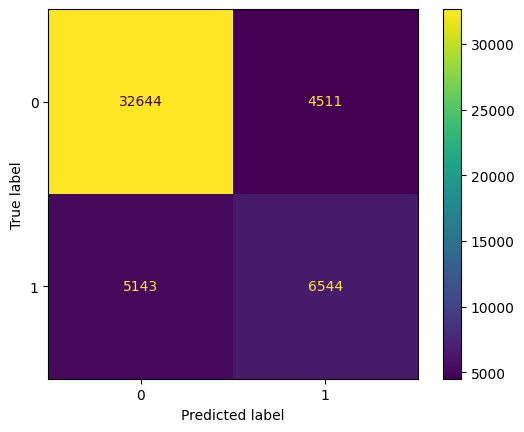

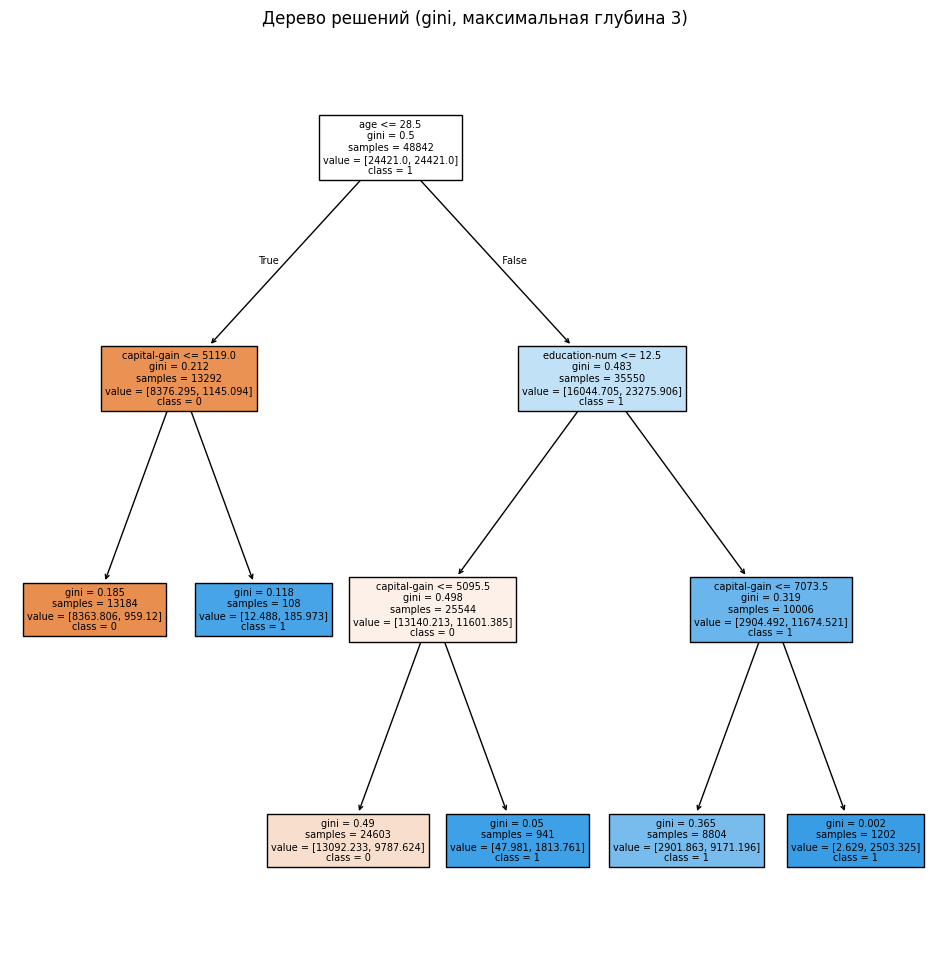

In [54]:
tree = make_decision_tree(data_df, y_df, 'gini', max_depth=3, max_leaf_cnt=6)
predicted_y = pd.Series(tree.predict(data_df))
metrics = calculate_metrics(y_df, predicted_y)

for metric in metrics.keys():
    print(f"{metric} = {metrics[metric]}")

visualise_confusion_matrix(y_df, predicted_y)
visualise_decision_tree(tree, data_df.columns.tolist(), "gini, максимальная глубина 3")

> Как можно увидеть, разработанный алгоритм рабочий. Правда значения данных метрик не является репрезентативными, так как модель обучалась на всей входной выборке. 

## **Задания 4-6**

4. Доработайте программу, добавив в список ее параметров долю, которую занимает обучающая выборка от общего размера набора данных, и обеспечив вычисление и выдачу в качестве результатов следующих показателей качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера.

5. Проведите эксперименты на наборе данных, фиксируя критерий выбора атрибута разбиения и варьируя соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 10%.

6. Выполните визуализацию полученных результатов в виде следующих диаграмм:

 - построенные деревья решений для заданного набора данных;
 - показатели качества классификации в зависимости от соотношения мощностей обучающей и тестовой выборок для заданного набора данных.

**************************************************
Доля тренировочных данных: 0.6
**************************************************
accuracy: 0.7189435430209347
precision: 0.4532753092075126
recall: 0.8466310160427808
f1_score: 0.5904378309838144
**************************************************
Доля тренировочных данных: 0.7
**************************************************
accuracy: 0.7184194362929093
precision: 0.4528158295281583
recall: 0.8485453508271534
f1_score: 0.5905121079793569
**************************************************
Доля тренировочных данных: 0.7999999999999999
**************************************************
accuracy: 0.7187020165830689
precision: 0.4531321444901692
recall: 0.8477331052181352
f1_score: 0.5905840286054828
**************************************************
Доля тренировочных данных: 0.8999999999999999
**************************************************
accuracy: 0.7148413510747186
precision: 0.44945848375451264
recall: 0.8520102651839179
f1_sco

Text(0.5, 0.98, 'Критерий: gini. Максиманльная глубина: 5')

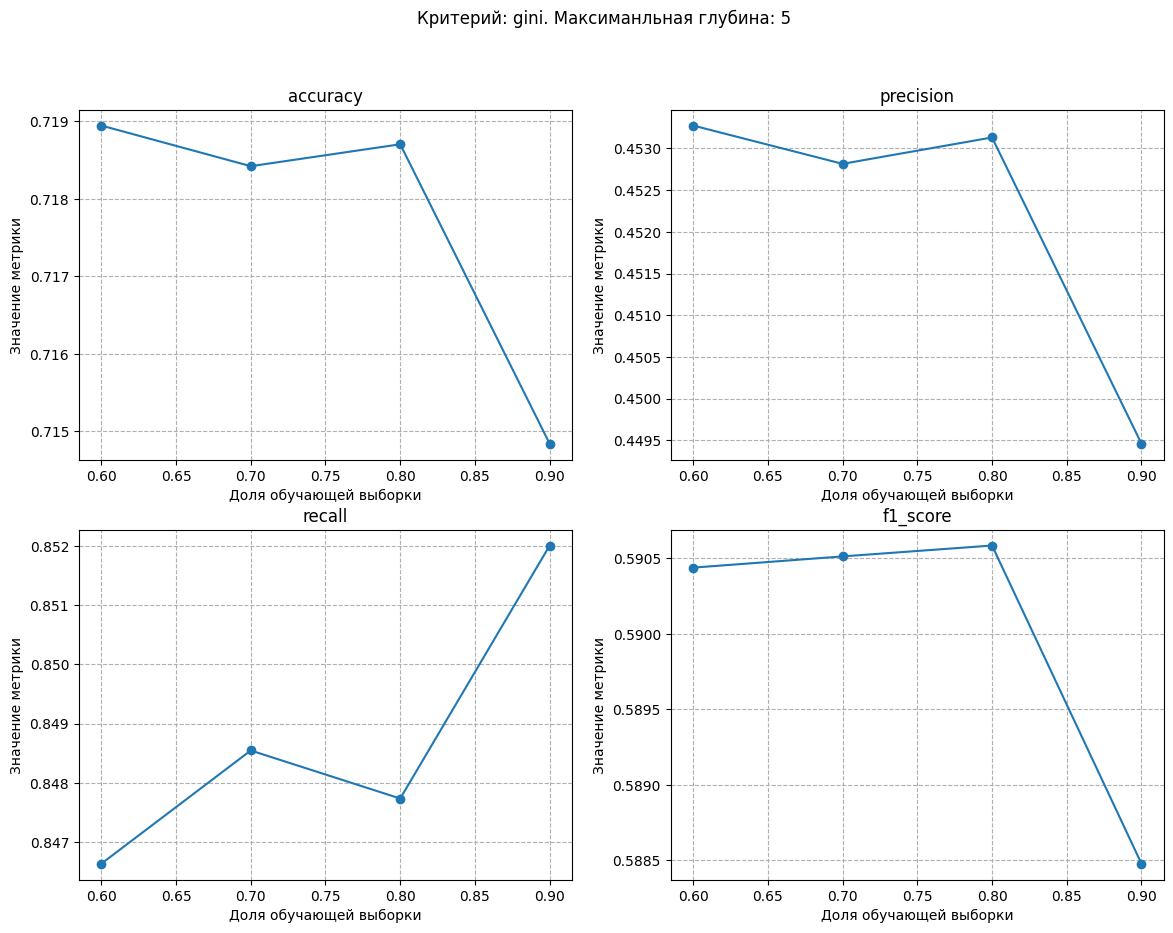

In [55]:
max_depth = 5
max_leaf_cnt = 8
criterion = 'gini' # ['gini', 'entropy', 'log_loss']

train_sizes = np.arange(0.6, 0.91, 0.1)
metrics_labels = ['accuracy', "precision", "recall", "f1_score"]
metrics = {label: [] for label in metrics_labels}

for train_size in list(train_sizes):
    X_train, X_test, y_train, y_test = train_test_split(
        data_df, y_df, train_size=train_size, random_state=35, stratify=y_df)
    X_train, X_test, y_train, y_test = (
        pd.DataFrame(X_train), pd.DataFrame(X_test), pd.Series(y_train), pd.Series(y_test))

    tree = make_decision_tree(X_train, y_train, criterion, max_depth=max_depth, max_leaf_cnt=max_leaf_cnt)
    predicted_y = pd.Series(tree.predict(X_test))
    local_metrics = calculate_metrics(y_test, predicted_y)
    for label in metrics.keys():
        metrics[label].append(local_metrics[label])

    print("*"*50, f"Доля тренировочных данных: {train_size}", "*"*50, sep="\n")
    for label in local_metrics.keys():
        print(f"{label}: {local_metrics[label]}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i in range(2):
    for j in range(2):
        index = i * 2 + j
        label = metrics_labels[index]
        axes[i,j].plot(train_sizes, metrics[label], marker='o')
        axes[i,j].set_title(label)
        axes[i,j].set_xlabel('Доля обучающей выборки')
        axes[i,j].set_ylabel('Значение метрики')
        axes[i,j].grid(True, linestyle='--')

fig.suptitle(f"Критерий: {criterion}. Максиманльная глубина: {max_depth}")

> Наилучшие результаты модели достигает при доле обучающей выборки 0,8

accuracy = 0.7187020165830689
precision = 0.4531321444901692
recall = 0.8477331052181352
f1_score = 0.5905840286054828


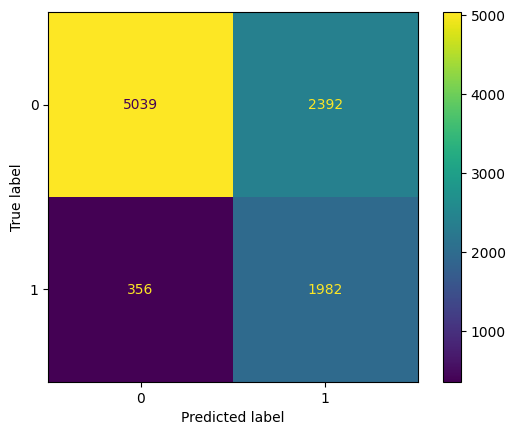

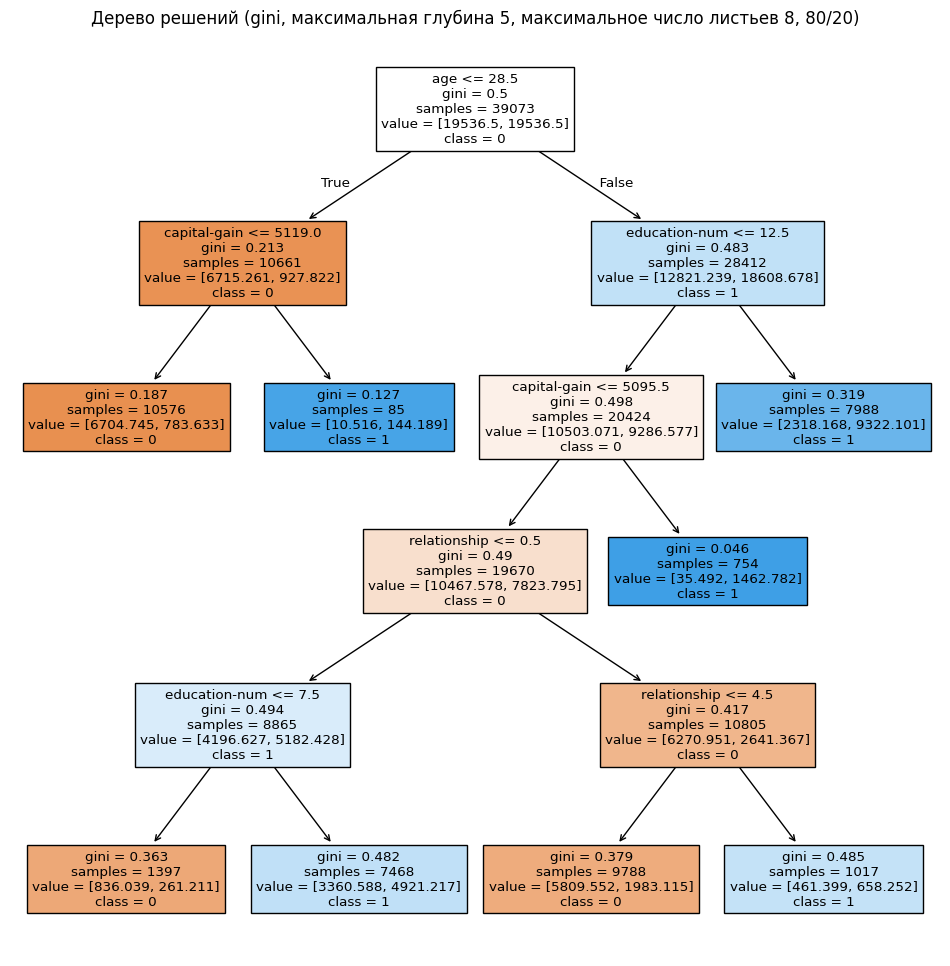

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    data_df, y_df, train_size=0.8, random_state=35, stratify=y_df)
X_train, X_test, y_train, y_test = (
    pd.DataFrame(X_train), pd.DataFrame(X_test), pd.Series(y_train), pd.Series(y_test))

tree = make_decision_tree(X_train, y_train, 'gini', max_depth=max_depth, max_leaf_cnt=max_leaf_cnt)
predicted_y = pd.Series(tree.predict(X_test))
metrics = calculate_metrics(y_test, predicted_y)

for metric in metrics.keys():
    print(f"{metric} = {metrics[metric]}")

visualise_confusion_matrix(y_test, predicted_y)
visualise_decision_tree(tree, data_df.columns.tolist(), 
                        f"gini, максимальная глубина {max_depth}, максимальное число листьев {max_leaf_cnt}, 80/20")

> Эксперементальным способом было выявлено, что наилучшие значения метрик получается при использовании максимальной глубина дерева решений 6 и максимально допустимом числе листьев 14.

> Как показано на матриче ошибок, модель чаще всего ошибается при выявлении позитивного класса `>50k`. Это связано с тем, что в входных данных есть разброс